                   model_name   Round model_type uniprot_type   
0                    MolCraft  Round1     denovo         seen  \
1                    MolCraft  Round1     denovo       unseen   
2                  DecompDiff  Round1     denovo         seen   
3                  DecompDiff  Round1     denovo       unseen   
4                        FLAG  Round1     denovo         seen   
5                        FLAG  Round1     denovo       unseen   
6                  PocketFlow  Round1     denovo         seen   
7                  PocketFlow  Round1     denovo       unseen   
8                     SurfGen  Round1     denovo         seen   
9                     SurfGen  Round1     denovo       unseen   
10                 TargetDiff  Round1     denovo         seen   
11                 TargetDiff  Round1     denovo       unseen   
12                     TamGen  Round1     denovo         seen   
13                     TamGen  Round1     denovo       unseen   
14                 Pocket

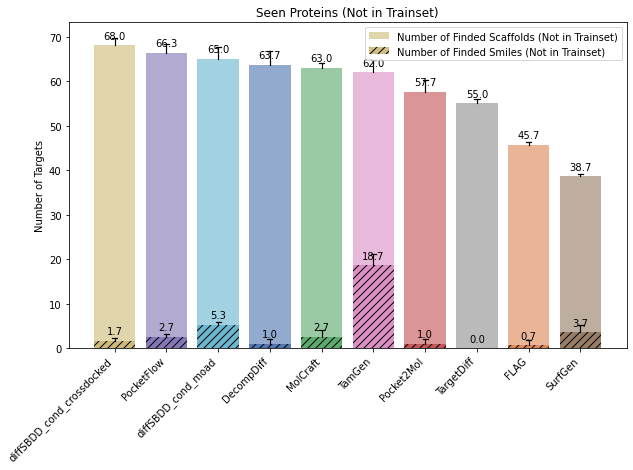

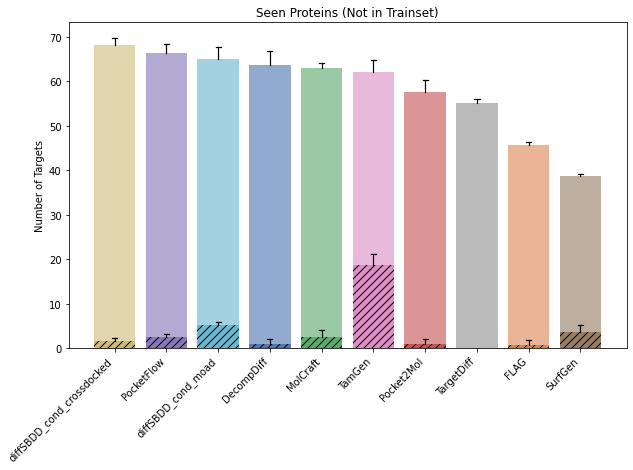

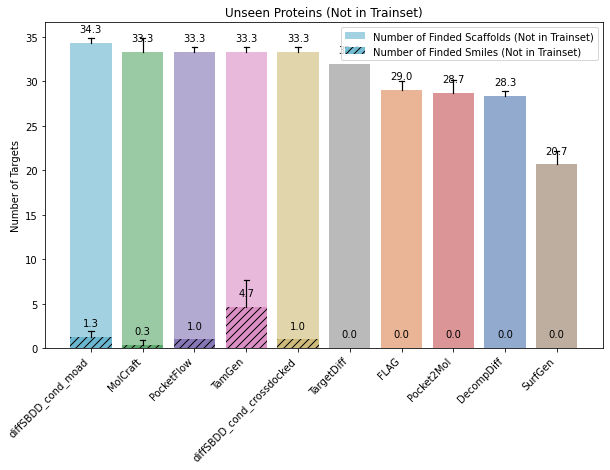

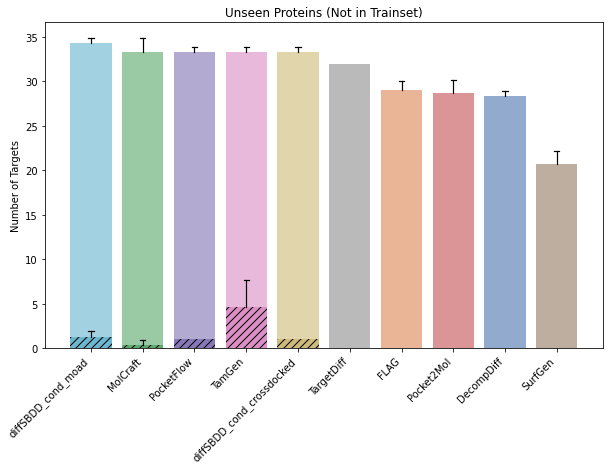

In [ ]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ========== 数据读取 ==========
data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"
save_fig_dir = "../final_plot/output/hit_recovery_not_in_trainset"

round_list = ["Round1", "Round2", "Round3"]
mode_list = ["De_novo_Results"]

TASK_LIST_DENOVO = [
    'MolCraft_generated_molecules',
    'DecompDiff_generated_molecules',
    'FLAG_generated_molecules',
    'PocketFlow_generated_molecules',
    'SurfGen_generated_molecules',
    'TargetDiff_generated_molecules',
    'TamGen_generated_molecules',
    "Pocket2Mol_generated_molecules",
    "diffSBDD_cond_crossdocked_generated_molecules",
    "diffSBDD_cond_moad_generated_molecules"
]

DENOVO_NAME_MAPPING = {
    "MolCraft_generated_molecules": "MolCraft",
    "DecompDiff_generated_molecules": "DecompDiff",
    "FLAG_generated_molecules": "FLAG",
    "PocketFlow_generated_molecules": "PocketFlow",
    "SurfGen_generated_molecules": "SurfGen",
    "TargetDiff_generated_molecules": "TargetDiff",
    "TamGen_generated_molecules": "TamGen",
    "Pocket2Mol_generated_molecules": "Pocket2Mol",
    "diffSBDD_cond_crossdocked_generated_molecules": "diffSBDD_cond_crossdocked",
    "diffSBDD_cond_moad_generated_molecules": "diffSBDD_cond_moad",
}

results_list = []
for round_name in round_list:
    for mode in mode_list:
        if mode == "De_novo_Results":
            task_list = TASK_LIST_DENOVO
            name_mapping = DENOVO_NAME_MAPPING
            task_type = "denovo"
            
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, mode, task, "results.yaml")
            if not os.path.exists(yaml_path):
                print(f"Warning: {yaml_path} not found")
                continue
                
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)

                for uniprot_type in ['seen', 'unseen']:
                    try:
                        smiles_hit = result['metrics']['HitRediscover'][uniprot_type]['smiles_hit_recovery_not_in_trainset']
                        scaffold_hit = result['metrics']['HitRediscover'][uniprot_type]['scaffold_hit_recovery_not_in_trainset']
                    except (KeyError, TypeError):
                        print(f"Warning: HitRediscover not found for {task} - {uniprot_type}")
                        smiles_hit = 0
                        scaffold_hit = 0
                        
                    results_list.append({
                        "model_name": name_mapping[task],
                        "Round": round_name,
                        "model_type": task_type,
                        "uniprot_type": uniprot_type,
                        "smiles_hit_recovery_not_in_trainset": smiles_hit,
                        "scaffold_hit_recovery_not_in_trainset": scaffold_hit,
                    })
                    

df_results = pd.DataFrame(results_list)
print(df_results)


# ========== 聚合数据 ==========
df_agg = (
    df_results
    .groupby(['model_name', 'model_type', 'uniprot_type'])
    .agg({
        'smiles_hit_recovery_not_in_trainset': ['mean', 'std'],
        'scaffold_hit_recovery_not_in_trainset': ['mean', 'std']
    })
    .reset_index()
)

df_agg.columns = [
    'ModelName', 'model_type', 'uniprot_type',
    'Number_of_Finded_Smiles_mean', 'Number_of_Finded_Smiles_std',
    'Number_of_Finded_Scaffolds_mean', 'Number_of_Finded_Scaffolds_std'
]

df_agg['Number_of_Finded_Smiles_std'] = df_agg['Number_of_Finded_Smiles_std'].fillna(0)
df_agg['Number_of_Finded_Scaffolds_std'] = df_agg['Number_of_Finded_Scaffolds_std'].fillna(0)

print(df_agg)


# ========== 绘图函数 ==========
def plot_hit_recovery(df_agg, uniprot_type='unseen', show_text=True, save_path=None):
    """
    绘制 Hit Recovery (Not in Trainset) 柱状图
    """
    df_plot = df_agg[df_agg['uniprot_type'] == uniprot_type].copy()
    
    if df_plot.empty:
        print(f"Warning: No data for uniprot_type={uniprot_type}")
        return
    
    # 按 scaffold 排序
    df_plot = df_plot.sort_values(by='Number_of_Finded_Scaffolds_mean', ascending=False).reset_index(drop=True)
    
    # ========== 绘图设置 ==========
    plt.figure(figsize=(10, 6))
    
    # 颜色设置：固定 n_colors=10，按字母排序分配颜色
    color_list = sns.color_palette("deep", n_colors=10)
    model_names = sorted(df_plot['ModelName'].tolist())
    color_map = {name: color_list[i % len(color_list)] for i, name in enumerate(model_names)}
    model_colors = [color_map[name] for name in df_plot['ModelName']]
    
    # 绘制柱状图
    bars1 = plt.bar(
        df_plot['ModelName'], 
        df_plot['Number_of_Finded_Scaffolds_mean'],
        label='Number of Finded Scaffolds (Not in Trainset)',
        alpha=0.6, 
        color=model_colors
    )
    
    bars2 = plt.bar(
        df_plot['ModelName'], 
        df_plot['Number_of_Finded_Smiles_mean'],
        label='Number of Finded Smiles (Not in Trainset)',
        alpha=0.9,
        hatch="///", 
        color=model_colors
    )
    
    # 设置 x 轴标签
    _ = plt.xticks(
        range(len(df_plot['ModelName'])), 
        df_plot['ModelName'], 
        rotation=45, 
        ha='right'
    )
    
    # 添加数值标注
    if show_text:
        for bar in bars1:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height + 1, 
                     f'{round(float(height), 1)}', ha='center', va='bottom')
        for bar in bars2:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height + 1, 
                     f'{round(float(height), 1)}', ha='center', va='bottom')
    
    # ========== 只画上半部分误差条 ==========
    for i, (mean, std) in enumerate(zip(
        df_plot['Number_of_Finded_Scaffolds_mean'],
        df_plot['Number_of_Finded_Scaffolds_std']
    )):
        if not np.isnan(std) and std > 0:
            bar = bars1[i]
            x = bar.get_x() + bar.get_width() / 2
            y = mean
            plt.plot([x, x], [y, y + std], color='black', linewidth=1.2)
            plt.plot([x - 0.05, x + 0.05], [y + std, y + std], color='black', linewidth=1.2)

    for i, (mean, std) in enumerate(zip(
        df_plot['Number_of_Finded_Smiles_mean'],
        df_plot['Number_of_Finded_Smiles_std']
    )):
        if not np.isnan(std) and std > 0:
            bar = bars2[i]
            x = bar.get_x() + bar.get_width() / 2
            y = mean
            plt.plot([x, x], [y, y + std], color='black', linewidth=1.2)
            plt.plot([x - 0.05, x + 0.05], [y + std, y + std], color='black', linewidth=1.2)
    
    plt.ylim(0, )
    plt.title(f'{uniprot_type.capitalize()} Proteins (Not in Trainset)')
    plt.ylabel('Number of Targets')
    if show_text:
        plt.legend()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=660, format='svg')
    
    plt.show()
    plt.close()


# ========== 调用绘图 ==========
os.makedirs(save_fig_dir, exist_ok=True)

# Seen Proteins - 带标注
plot_hit_recovery(
    df_agg, 
    uniprot_type='seen', 
    show_text=True,
    save_path=os.path.join(save_fig_dir, "hit_recovery_not_in_trainset_seen_with_text.svg")
)

# Seen Proteins - 不带标注
plot_hit_recovery(
    df_agg, 
    uniprot_type='seen', 
    show_text=False,
    save_path=os.path.join(save_fig_dir, "hit_recovery_not_in_trainset_seen_no_text.svg")
)

# Unseen Proteins - 带标注
plot_hit_recovery(
    df_agg, 
    uniprot_type='unseen', 
    show_text=True,
    save_path=os.path.join(save_fig_dir, "hit_recovery_not_in_trainset_unseen_with_text.svg")
)

# Unseen Proteins - 不带标注
plot_hit_recovery(
    df_agg, 
    uniprot_type='unseen', 
    show_text=False,
    save_path=os.path.join(save_fig_dir, "hit_recovery_not_in_trainset_unseen_no_text.svg")
)